<div style="
    background-color: #F4F6F7; 
    color: #2C3E50; 
    padding: 20px; 
    text-align: center; 
    border-radius: 10px; 
    border-left: 8px solid #5F9EA0; 
    font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; 
    box-shadow: 0 4px 6px rgba(0,0,0,0.1);
">
    <h1 style="margin: 0; padding-bottom: 5px;">
        NYC Taxi Pickup Hotspots
    </h1>
    <h3 style="margin-top: 15px; font-weight: normal; font-style: italic; color: #34495E;">
        Unsupervised Clustering Assignment (K-Means + DBSCAN)
    </h3>
</div>

<h2 style="
    color: #3A6F73;
    font-size: 22px;
    margin-top: 30px;
    font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
    border-bottom: 2px solid #E0E6E8;
    padding-bottom: 8px;
">
📑 Table of Contents</h2>

| Section | Description |
| :--- | :--- |
| **1. Setup & Data Ingestion** | Load multiple `yellow_tripdata_*.csv` safely (chunking + sampling). |
| **2. Geospatial EDA + OSM** | Clean coordinates and visualize density on OpenStreetMap. |
| **3. Aggregation** | Aggregate pickups to a grid so clustering is fast. |
| **4. K-Means** | Choose $K$ and interpret hotspot clusters. |
| **5. DBSCAN** | Find dense pickup areas without choosing $K$. |
| **6. Deliverables** | Answer questions + include maps and interpretation. |

<h1 style="
    background-color: #F4F6F7;
    color: #2C3E50;
    padding: 20px;
    text-align: center;
    border-radius: 10px;
    border-left: 8px solid #5F9EA0;
    font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
    box-shadow: 0 4px 6px rgba(0,0,0,0.1);
">
Project Context</h1>

Deze dataset bevat taxi-ritten uit New York en werd oorspronkelijk gepubliceerd door de
NYC Taxi & Limousine Commission (TLC).
Belangrijkste features

Typische variabelen zijn bijvoorbeeld:
pickup_latitude
pickup_longitude
dropoff_latitude
dropoff_longitude
pickup_datetime
passenger_count
trip_duration
fare_amount

Elke rij stelt één taxi-rit voor met GPS-coördinaten van pickup en drop-off.

Dat betekent dat je miljoenen spatial punten hebt waar mensen taxi’s nemen.

De onderzoeksvraag luidt:

“Kunnen we met clustering technieken natuurlijke taxi-pickup hotspots in New York identificeren?”

De data kan je hier vinden: https://www.kaggle.com/datasets/elemento/nyc-yellow-taxi-trip-data/data

Sla deze data op in je DATA folder (zoals we voor de andere oefeningen notebooks doen).


<h1 style="
    background-color: #F4F6F7;
    color: #2C3E50;
    padding: 20px;
    text-align: center;
    border-radius: 10px;
    border-left: 8px solid #5F9EA0;
    font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
    box-shadow: 0 4px 6px rgba(0,0,0,0.1);
">
1. Setup & Data Ingestion</h1>

### 📝 Opdracht 1 — Imports & Visualisatie-instellingen

Importeer de nodige bibliotheken en stel de visualisatie-instellingen in:

- Importeer `numpy` als `np`, `pandas` als `pd`, `matplotlib.pyplot` als `plt`, `seaborn` als `sns`
- Importeer `KMeans` en `DBSCAN` uit `sklearn.cluster`
- Importeer `StandardScaler` uit `sklearn.preprocessing`
- Importeer `silhouette_score` uit `sklearn.metrics`
- Schakel waarschuwingen uit met `warnings.filterwarnings('ignore')`
- Stel de stijl in met `sns.set(style='whitegrid')` en het opgegeven kleurenpalet
- Stel de standaard figuurgrootte in op `(10, 6)` via `plt.rcParams`

In [ ]:
from __future__ import annotations

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

warnings.filterwarnings(...)

teal_corporate_palette = ['#5F9EA0', '#2F4F4F', '#3CB371', '#20B2AA', '#008080']
sns.set(style='whitegrid')
sns.set_palette(teal_corporate_palette)
plt.rcParams['figure.figsize'] = (10, 6)

print('Imports OK ✅')

Imports OK ✅


### 📝 Opdracht 2 — DATA-map opzoeken & CSV-bestanden laden

Schrijf een functie `find_data_dir()` die vanuit de huidige werkmap stap voor stap omhoog loopt om de `DATA/`-map te vinden.

- Loop over `[start, *start.parents]` en check bij elke stap of `parent / 'DATA'` bestaat en een map is.
- Retourneer het gevonden pad of gooi een `FileNotFoundError`.

Gebruik daarna `sorted()` met `Path.glob('yellow_tripdata_*.csv')` om alle relevante bestanden te vinden en print het resultaat.

In [ ]:
def find_data_dir(start: Path | None = None, max_levels: int = 8) -> Path:
    """Loop omhoog vanuit 'start' om de data/-map te vinden."""
    if start is None:
        start = Path.cwd()
    start = start.resolve()
    for level, parent in enumerate([start, *start.parents]):
        if level > max_levels:
            break
        candidate = parent / 'data'
        if candidate.exists() and candidate.is_dir():
            return candidate
    raise FileNotFoundError('Could not find a DATA/ folder by walking upward from the current working directory.')

DATA_DIR = find_data_dir()
trip_files = sorted(DATA_DIR.glob('yellow_tripdata_*.csv'))
print('DATA_DIR:', DATA_DIR)
print('Found files:', len(trip_files))
for f in trip_files:
    print(' -', f.name)

assert len(trip_files) > 0, 'No yellow_tripdata_*.csv files found in data/'

### 📝Configuratie

Volgende variabelen zijn gedefinieerd voor jou. Vermits de data heel groot is, kan je dus best starten met een subsample.

| Constante | Beschrijving | Waarde |
|---|---|---|
| `MAX_FILES` | Aantal te gebruiken bestanden | `2` |
| `RANDOM_STATE` | Seed voor reproduceerbaarheid | `42` |
| `CHUNKSIZE` | Rijen per chunk bij inladen | `200_000` |
| `SAMPLE_FRAC_PER_CHUNK` | Fractie per chunk die bewaard wordt | `0.05` |
| `MAX_POINTS_FOR_DBSCAN` | Maximum punten voor DBSCAN | `80_000` |

Selecteer daarna de eerste `MAX_FILES` bestanden uit `trip_files` en print de namen.

In [47]:
MAX_FILES = 2
RANDOM_STATE = 42
CHUNKSIZE = 200_000
SAMPLE_FRAC_PER_CHUNK = 0.05
MAX_POINTS_FOR_DBSCAN = 80_000

selected_files = trip_files[:MAX_FILES]
print('Selected files:')
for f in selected_files:
    print(' -', f.name)

Selected files:
 - yellow_tripdata_2015-01.csv
 - yellow_tripdata_2016-01.csv


### 📝 Data inladen (chunking + sampling)

De functie `load_pickups()` leest de CSV-bestanden in stukken (chunks) en behoudt enkel een steekproef per chunk.

via helperfuncties en `load_pickups()`:

1. De juiste kolomnamen opzoeken via `_first_existing()` (lat, lon, datetime)
2. Kolomnamen standaardiseren naar `pickup_lat`, `pickup_lon`, `pickup_datetime` in `standardize_trip_columns()`
3. Rijen buiten het NYC-begrenzingskader verwijderen in `filter_nyc_bbox()`
4. Per chunk: kolomnamen standaardiseren, naar numeriek omzetten, filterenop NYC-bbox, en een steekproef trekken op basis van `SAMPLE_FRAC_PER_CHUNK`
5. Alle chunks samenvoegen tot één `DataFrame`

Daarna wordt `load_pickups(selected_files)` opgeroepen en het aantal rijen geprint.

In [ ]:
NYC_BOUNDS = {'lat_min': 40.50, 'lat_max': 41.05, 'lon_min': -74.30, 'lon_max': -73.60}
PICKUP_LAT_CANDIDATES = ['pickup_latitude', 'pickup_lat']
PICKUP_LON_CANDIDATES = ['pickup_longitude', 'pickup_lon']
PICKUP_DT_CANDIDATES = ['tpep_pickup_datetime', 'pickup_datetime']

def _first_existing(cols: list[str], candidates: list[str]) -> str | None:
    """Geeft de eerste kolomnaam terug die voorkomt in 'candidates' (hoofdletterongevoelig)."""
    cols_lower = {c.lower(): c for c in cols}
    for cand in candidates:
        if cand.lower() in cols_lower:
            return cols_lower[cand.lower()]
    return None

def standardize_trip_columns(df: pd.DataFrame) -> pd.DataFrame:
    lat_col = _first_existing(list(df.columns), PICKUP_LAT_CANDIDATES)
    lon_col = _first_existing(list(df.columns), PICKUP_LON_CANDIDATES)
    dt_col = _first_existing(list(df.columns), PICKUP_DT_CANDIDATES)
    if lat_col is None or lon_col is None:
        raise ValueError('Could not find pickup lat/lon columns in this file.')
    rename_map = {lat_col: 'pickup_lat', lon_col: 'pickup_lon'}
    if dt_col is not None:
        rename_map[dt_col] = 'pickup_datetime'
    return df.rename(columns=rename_map)

def filter_nyc_bbox(df: pd.DataFrame) -> pd.DataFrame:
    return df[(df['pickup_lat'].between(NYC_BOUNDS['lat_min'], NYC_BOUNDS['lat_max'])) & (df['pickup_lon'].between(NYC_BOUNDS['lon_min'], NYC_BOUNDS['lon_max']))]

def load_pickups(files: list[Path]) -> pd.DataFrame:
    chunks: list[pd.DataFrame] = []
    for file_path in files:
        header = pd.read_csv(file_path, nrows=0)
        lat_col = _first_existing(list(header.columns), PICKUP_LAT_CANDIDATES)
        lon_col = _first_existing(list(header.columns), PICKUP_LON_CANDIDATES)
        dt_col = _first_existing(list(header.columns), PICKUP_DT_CANDIDATES)
        if lat_col is None or lon_col is None:
            raise ValueError('Missing pickup columns in: {}'.format(file_path.name))
        usecols = [lat_col, lon_col] + ([dt_col] if dt_col is not None else [])
        for chunk in pd.read_csv(file_path, usecols=usecols, chunksize=CHUNKSIZE, low_memory=False):
            chunk = standardize_trip_columns(chunk)
            chunk['pickup_lat'] = pd.to_numeric(chunk['pickup_lat'], errors='coerce')
            chunk['pickup_lon'] = pd.to_numeric(chunk['pickup_lon'], errors='coerce')
            if 'pickup_datetime' in chunk.columns:
                chunk['pickup_datetime'] = pd.to_datetime(chunk['pickup_datetime'], errors='coerce')
            chunk = chunk.dropna(subset=['pickup_lat', 'pickup_lon'])
            chunk = filter_nyc_bbox(chunk)
            if SAMPLE_FRAC_PER_CHUNK is not None and 0 < SAMPLE_FRAC_PER_CHUNK < 1:
                chunk = chunk.sample(frac=SAMPLE_FRAC_PER_CHUNK, random_state=RANDOM_STATE)
            chunks.append(chunk)
    return pd.concat(chunks, ignore_index=True)


pickups = load_pickups(selected_files)
print('Loaded pickups:', len(pickups))
pickups.head()

<h1 style="
    background-color: #F4F6F7;
    color: #2C3E50;
    padding: 20px;
    text-align: center;
    border-radius: 10px;
    border-left: 8px solid #5F9EA0;
    font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
    box-shadow: 0 4px 6px rgba(0,0,0,0.1);
">
2. Geospatial EDA + OpenStreetMap</h1>

### 📝 Opdracht 5 — EDA: Beschrijvende statistieken

Toon beschrijvende statistieken voor de kolommen `pickup_lat` en `pickup_lon`.

- Gebruik `percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]`
- Wat valt je op aan de minimale/maximale waarden? Zijn er uitschieters?

> 💡 `df[['col1', 'col2']].describe(percentiles=[...])`

In [ ]:
# TODO: toon beschrijvende statistieken voor pickup_lat en pickup_lon
# Gebruik percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]


### 📝 Opdracht 6 — EDA: Histogrammen van lat/lon

Maak een figuur met **2 histogrammen naast elkaar** (1 rij, 2 kolommen):

- Links: verdeling van `pickup_lat` met 60 bins  
- Rechts: verdeling van `pickup_lon` met 60 bins  
- Voeg passende titels toe

> 💡 Gebruik `plt.subplots(1, 2)` en `sns.histplot(...)` per as.

In [ ]:
# TODO: maak een figuur met 2 histogrammen naast elkaar (figsize=(12, 4))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# TODO: plot een histogram van pickup_lat (60 bins) op axes[0]

# TODO: plot een histogram van pickup_lon (60 bins) op axes[1]

# TODO: voeg titels toe aan beide assen en roep plt.tight_layout() en plt.show() aan


### 📝 Opdracht 7 — EDA: Scatter plot van pickup-locaties

Trek een steekproef van maximaal **30 000 punten** en maak een scatter plot:

- X-as: `pickup_lon`, Y-as: `pickup_lat`
- Gebruik kleine punten (`s=1`) en lage transparantie (`alpha=0.25`)
- Voeg een titel toe met het steekproefaantal en zinvolle aslabels

> 💡 `pickups.sample(n=..., random_state=RANDOM_STATE)`

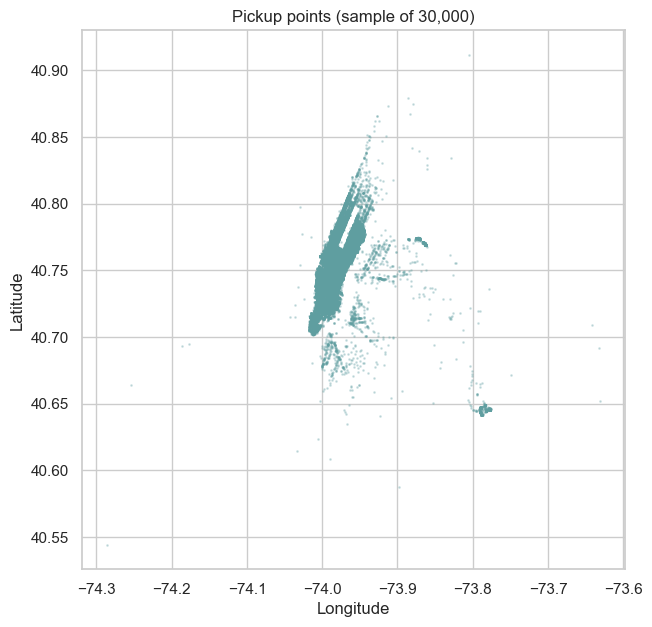

In [ ]:
# TODO: bereken sample_n als het minimum van 30_000 en het totale aantal pickups
sample_n = ...

# TODO: Trek een steekproef van sample_n punten uit pickups (random_state=RANDOM_STATE)
sample = ...

# TODO: maak een scatter plot van pickup_lon (x-as) vs pickup_lat (y-as)
# Gebruik figsize=(7, 7), s=1, alpha=0.25
# Voeg een titel toe met het steekproefaantal en zinvolle aslabels
plt.figure(figsize=(7, 7))

plt.show()

### 📝 Interactieve Folium Heatmap

Maak een interactieve kaart met `folium.Map` gecentreerd op NYC (`[40.75, -73.98]`) en voeg een `HeatMap` toe:

1. Maak een `folium.Map` met `tiles='OpenStreetMap'` en `zoom_start=11`
2. Trek een steekproef van maximaal **50 000 punten** uit `pickups`
3. Converteer `pickup_lat` en `pickup_lon` naar een lijst van `[lat, lon]`-paren → `heat_data`
4. Maak een `HeatMap(heat_data, radius=9, blur=12, min_opacity=0.2)` en voeg toe aan de kaart
5. Sla de kaart op als `map.html` en toon ze in de notebook

> 💡 `from folium.plugins import HeatMap` — gebruik `.to_numpy().tolist()` voor de conversie.

In [ ]:
import folium
from folium.plugins import HeatMap

map_center = [40.75, -73.98]
m = folium.Map(location=map_center, tiles='OpenStreetMap', zoom_start=11, control_scale=True)
heat_n = min(50_000, len(pickups))
heat_df = pickups.sample(n=heat_n, random_state=RANDOM_STATE)
heat_data = heat_df[['pickup_lat', 'pickup_lon']].to_numpy().tolist()
HeatMap(heat_data, radius=9, blur=12, min_opacity=0.2).add_to(m)
m.save("map.html")
m

<h1 style="
    background-color: #F4F6F7;
    color: #2C3E50;
    padding: 20px;
    text-align: center;
    border-radius: 10px;
    border-left: 8px solid #5F9EA0;
    font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
    box-shadow: 0 4px 6px rgba(0,0,0,0.1);
">
3. Aggregation</h1>

### 📝 Grid-aggregatie van pickup-punten

In plaats van alle ruwe punten te clusteren, aggregeren we eerst naar een rooster. Dit maakt clustering veel sneller.

Stappen:

1. Maak een kopie van `pickups` → `binned`
2. Rond `pickup_lat` af op `GRID_DECIMALS` decimalen → nieuwe kolom `lat_bin`
3. Rond `pickup_lon` af op `GRID_DECIMALS` decimalen → nieuwe kolom `lon_bin`
4. Groepeer per `(lat_bin, lon_bin)`, tel het aantal rijen → kolom `pickup_count`
5. Sorteer aflopend op `pickup_count` en sla op als `grid`

Print het aantal rastercellen en toon de top-10.

> 💡 `df.groupby([...]).size().reset_index(name='pickup_count')`

In [ ]:
GRID_DECIMALS = 5
binned = pickups.copy()
binned['lat_bin'] = binned['pickup_lat'].round(GRID_DECIMALS)
binned['lon_bin'] = binned['pickup_lon'].round(GRID_DECIMALS)
grid = binned.groupby(['lat_bin', 'lon_bin']).size().reset_index(name='pickup_count').sort_values('pickup_count', ascending=False)
print('Grid cells:', len(grid))
grid.head(10)

### 📝 Opdracht 10 — Kaart: Top rastercellen als cirkels

Visualiseer de **top 2 000 rastercellen** als cirkels op een folium-kaart, waarbij de straal de drukte weergeeft:

1. Bereken `counts_log = np.log1p(pickup_count)` voor de top-2000 cellen
2. Schaal de cirkelstraal lineair tussen `min_r = 2` en `max_r = 14` op basis van `counts_log`
3. Loop over de cellen en voeg `folium.CircleMarker` toe:
   - `color='#008080'`, `fill=True`, `fill_opacity=0.45`
   - Tooltip met het aantal pickups: `'Pickups: {:,}'`
4. Sla op als `m2_map.html`

> 💡 Schalingsformule: `r = min_r + (val - val_min) / (val_max - val_min) * (max_r - min_r)`

In [ ]:
m2 = folium.Map(location=map_center, tiles='OpenStreetMap', zoom_start=11, control_scale=True)
top_n = 2000
grid_top = grid.head(top_n).copy()
counts = grid_top['pickup_count'].to_numpy()
counts_log = np.log1p(counts)
min_r, max_r = 2, 14
radii = min_r + (counts_log - counts_log.min()) / (counts_log.max() - counts_log.min() + 1e-9) * (max_r - min_r)
for (lat, lon, count, rad) in zip(grid_top['lat_bin'], grid_top['lon_bin'], grid_top['pickup_count'], radii):
    folium.CircleMarker(location=[float(lat), float(lon)], radius=float(rad), color='#008080', fill=True, fill_opacity=0.45, weight=1, tooltip='Pickups: {:,}'.format(int(count))).add_to(m2)
m2.save("m2_map.html")
m2

<h1 style="
    background-color: #F4F6F7;
    color: #2C3E50;
    padding: 20px;
    text-align: center;
    border-radius: 10px;
    border-left: 8px solid #5F9EA0;
    font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
    box-shadow: 0 4px 6px rgba(0,0,0,0.1);
">
4. K-Means Hotspot Clustering</h1>

### 📝 Opdracht 11 — Data voorbereiden voor K-Means

K-Means werkt op numerieke vectoren. Bereid de data voor:

1. Extraheer de coördinaten als NumPy-array: `X = grid[['lon_bin', 'lat_bin']].to_numpy(dtype=float)`
2. Extraheer de gewichten: `w = grid['pickup_count'].to_numpy(dtype=float)`
3. Standaardiseer `X` met `StandardScaler` → `X_scaled`
4. Trek een steekproef van maximaal `KMEANS_MAX_POINTS = 10_000` punten voor snellere training:
   - Gebruik `np.random.default_rng(RANDOM_STATE).choice(n_points, size=sample_size, replace=False)`
   - Sla op als `X_scaled_sample` en `w_sample`

Print de shapes van alle arrays.

> 💡 Waarom standaardiseren? Geografische coördinaten hebben kleine absolute waarden — `StandardScaler` zorgt voor gelijke bijdrage van lat en lon.

In [18]:
X = grid[['lon_bin', 'lat_bin']].to_numpy(dtype=float)
w = grid['pickup_count'].to_numpy(dtype=float)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Sample for faster KMeans (reproducible)
KMEANS_MAX_POINTS = 10_000
rng = np.random.default_rng(RANDOM_STATE)
n_points = X_scaled.shape[0]
sample_size = min(KMEANS_MAX_POINTS, n_points)
sample_idx = rng.choice(n_points, size=sample_size, replace=False)
X_scaled_sample = X_scaled[sample_idx]
w_sample = w[sample_idx]

X_scaled.shape, w.shape, X_scaled_sample.shape, w_sample.shape

((1040037, 2), (1040037,), (10000, 2), (10000,))

### 📝 Opdracht 12 — Optimale K bepalen (Elbow & Silhouette)

Test K-waarden van 2 t/m 12 en bepaal de optimale K via twee methoden:

**Voor elke K:**
1. Train `KMeans(n_clusters=k, n_init='auto', random_state=RANDOM_STATE)`
2. Fit op `X_scaled_sample` met `sample_weight=w_sample`
3. Bewaar `km.inertia_` → lijst `inertias`
4. Bereken `silhouette_score(X_scaled_sample, km.labels_)` → lijst `silhouettes`

**Visualisatie:**
- Plot de **Elbow-curve**: K (x-as) vs. inertia (y-as)
- Plot de **Silhouette-score**: K (x-as) vs. silhouette (y-as)

> 🤔 Welke K kies je op basis van beide grafieken? Noteer je keuze als `FINAL_K` in de volgende cel.

In [ ]:
K_values = list(range(2, 13))
inertias = []
silhouettes = []

# TODO: loop over K_values
for k in K_values:
    # TODO: maak een KMeans aan met n_clusters=k, n_init='auto', random_state=RANDOM_STATE
    km = ...
    # TODO: fit op X_scaled_sample met sample_weight=w_sample
    # TODO: bewaar km.inertia_ in inertias
    # TODO: bereken silhouette_score(X_scaled_sample, km.labels_) en bewaar in silhouettes
    #       (gebruik np.nan als er slechts 1 uniek label is)
    pass

# TODO: plot de Elbow-curve (K vs. inertia)
plt.figure(figsize=(10, 4))

plt.show()
plt.figure(figsize=(10, 4))

plt.show()

### 📝 Opdracht 13 — K-Means trainen & clusters toewijzen

1. Pas `FINAL_K` aan op basis van je analyse in opdracht 12
2. Train een `KMeans`-model met `FINAL_K` clusters op de steekproef (`X_scaled_sample`), gewogen met `w_sample`. Zoek uit hoe je dit doet adhv sklearn documentatie!
3. Voorspel het cluster voor **alle** rastercellen: gebruik `kmeans.predict(X_scaled)` → voeg toe als kolom `cluster` aan `grid_km`
4. Transformeer de clustercentra terug naar originele lat/lon-coördinaten via `scaler.inverse_transform(kmeans.cluster_centers_)`
5. Sla op in `centers_df` met kolommen `lon_center`, `lat_center`, `cluster` en toon het resultaat

> 💡 Waarom fitten op steekproef maar predicten op alle punten? Dit scheelt rekentijd terwijl alle punten toch een label krijgen.

In [ ]:
FINAL_K = 7  # TODO: pas aan op basis van de Elbow- en Silhouette-grafieken

# TODO: train een KMeans-model met FINAL_K clusters op X_scaled_sample, gewogen met w_sample
kmeans = ...

# TODO: maak een kopie van grid → grid_km
grid_km = grid.copy()
# TODO: voorspel het cluster voor ALLE punten in X_scaled en voeg toe als kolom 'cluster'
grid_km['cluster'] = ...

# TODO: transformeer de clustercentra terug naar originele lat/lon via scaler.inverse_transform()
centers = ...

centers_df = pd.DataFrame(centers, columns=['lon_center', 'lat_center'])
centers_df['cluster'] = range(FINAL_K)
centers_df

### 📝 K-Means clusters visualiseren op kaart

Maak een folium-kaart en kleur de rastercellen per cluster:

1. Loop over de top **3 000 rastercellen** uit `grid_km`
2. Kleur elke cirkel op basis van het cluster: `palette[int(row['cluster']) % len(palette)]`
3. Gebruik `radius=3`, `fill=True`, `fill_opacity=0.5` en voeg een tooltip toe
4. Voeg ook **clustercentra** toe als `folium.Marker` met een groen icoon (`color='darkgreen'`)
5. Sla op als `m3_map.html`

> 🤔 Wat stellen de clusters geografisch voor? Herken je bekende NYC-locaties (JFK, Manhattan, …)?

In [23]:
m3 = folium.Map(location=map_center, tiles='OpenStreetMap', zoom_start=11, control_scale=True)
palette = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
grid_vis = grid_km.head(3000).copy()
for _, row in grid_vis.iterrows():
    color = palette[int(row['cluster']) % len(palette)]
    tooltip = 'cluster={}, pickups={:,}'.format(int(row['cluster']), int(row['pickup_count']))
    folium.CircleMarker(location=[float(row['lat_bin']), float(row['lon_bin'])], radius=3, color=color, fill=True, fill_opacity=0.5, weight=1, tooltip=tooltip).add_to(m3)
for _, row in centers_df.iterrows():
    folium.Marker(location=[float(row['lat_center']), float(row['lon_center'])], tooltip='KMeans center: cluster {}'.format(int(row['cluster'])), icon=folium.Icon(color='darkgreen', icon='info-sign')).add_to(m3)
m3.save("m3_map.html")

<h1 style="
    background-color: #F4F6F7;
    color: #2C3E50;
    padding: 20px;
    text-align: center;
    border-radius: 10px;
    border-left: 8px solid #5F9EA0;
    font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
    box-shadow: 0 4px 6px rgba(0,0,0,0.1);
">
5. DBSCAN Hotspots & Noise</h1>

### 📝 Opdracht 15 — DBSCAN uitvoeren

In tegenstelling tot K-Means vereist DBSCAN geen vooraf gekozen K, maar wel twee parameters: `eps` (buurtstraal) en `min_samples`.

Stappen:

1. Trek een steekproef van maximaal `MAX_POINTS_FOR_DBSCAN` punten uit `pickups` → kolommen `pickup_lat`, `pickup_lon`
2. Zet coördinaten om naar **radialen**: `coords_rad = np.radians(...)` — haversine-metric verwacht radialen
3. Stel `eps_meters` in (begin met 300) en `min_samples` (begin met 50)
4. Maak DBSCAN aan met metric='haversine' (De Haversine-formule berekent de werkelijke afstand over het aardoppervlak (orthodromische afstand / "great-circle distance") tussen twee punten)
5. Voer `fit_predict(coords_rad)` uit → sla labels op in `db['dbscan_label']`
6. Print het aantal clusters en de ruisfractie

> 💡 Label `-1` = ruispunt. Stem de parameters bij totdat het aantal clusters zinvol is (niet ≈ 1 of ≈ n_punten).
> `EARTH_RADIUS_M = 6_371_000`

In [ ]:
dbscan_n = min(MAX_POINTS_FOR_DBSCAN, len(pickups))
db = pickups.sample(n=dbscan_n, random_state=RANDOM_STATE)[['pickup_lat', 'pickup_lon']].copy()
coords_rad = np.radians(db[['pickup_lat', 'pickup_lon']].to_numpy(dtype=float))
EARTH_RADIUS_M = 6_371_000
eps_meters = 20  # TODO: tune (300) ahv de visualisatie verder
# eps = eps_meters / EARTH_RADIUS_M (gebruik deze formule in DBSCAN)
min_samples = 25  # TODO: tune (50) ahv de visualisatie verder
dbscan = ...
labels = ... 
db['dbscan_label'] = labels

# Hoeveel clusters hebben we?
n_clusters = ...
noise_frac = ...
print('DBSCAN clusters:', n_clusters)
print('Noise fraction: {:.2%}'.format(noise_frac))
db['dbscan_label'].value_counts().head(10)

### 📝 Opdracht 16 — DBSCAN visualiseren: cluster vs. ruis

Maak een scatter plot om te zien welke punten als ruis zijn geclassificeerd:

- **Rood** (`color='red'`): punten met `dbscan_label == -1` (ruis)
- **Groen** (`color='green'`): geclusterde punten (`dbscan_label != -1`)
- Gebruik `s=1`, `alpha=0.3`–`0.5` voor leesbaarheid
- Voeg een titel, aslabels en een `plt.legend()` toe

> 🤔 Wat betekent een hoge ruisfractie? Hoe zou je `eps_meters` of `min_samples` aanpassen om minder ruis te krijgen?

In [ ]:
plt.figure(figsize=(7, 7))

# TODO: maak een booleaanse reeks is_noise waarbij dbscan_label == -1
is_noise = ...

# TODO: scatter plot van ruispunten (rood, s=1, alpha=0.3, label='noise')

# TODO: scatter plot van geclusterde punten (groen, s=1, alpha=0.5, label='clustered')
core = db.loc[~is_noise]

# TODO: voeg een titel, aslabels en plt.legend() toe
plt.show()

### 📝 DBSCAN cluster-centroids berekenen

Bereken de centroïden van alle gevonden DBSCAN-clusters (zonder ruispunten):

1. Filter `db` zodat enkel geclusterde punten overblijven (`dbscan_label != -1`) → `clustered`
2. Groepeer per `dbscan_label` en bereken:
   - Gemiddelde `pickup_lat` en `pickup_lon` → centroïd van het cluster
   - Cluster grootte → kolom `n`
3. Sorteer aflopend op `n` → `centroids`
4. Toon de top-10

> 💡 `df.groupby('col').agg(new_col=('src_col', 'agg_func'))`

In [ ]:
clustered = db[db['dbscan_label'] != -1].copy()
centroids = clustered.groupby('dbscan_label').agg(pickup_lat=('pickup_lat', 'mean'), pickup_lon=('pickup_lon', 'mean'), n=('dbscan_label', 'size')).reset_index().sort_values('n', ascending=False)
centroids.head(10)

### 📝 Top DBSCAN-clusters op kaart

Teken de **top 20 DBSCAN-clusters** als rode cirkels op een folium-kaart:

1. Maak een nieuwe `folium.Map` gecentreerd op NYC
2. Loop over `centroids.head(20)` en voeg per cluster een `folium.CircleMarker` toe:
   - `color='#d62728'` (rood), `radius=6`, `fill=True`, `fill_opacity=0.75`
   - Tooltip: `'DBSCAN cluster {label}: n={n:,}'`
3. Sla op als `m4_map.html`

> 🤔 Vergelijk deze kaart met de K-Means kaart (`m3`). Welke methode vindt meer gedetailleerde hotspots?

In [ ]:
m4 = folium.Map(location=map_center, tiles='OpenStreetMap', zoom_start=11, control_scale=True)
top_clusters = centroids.head(20).copy()
for _, row in top_clusters.iterrows():
    tooltip = 'DBSCAN cluster {}: n={:,}'.format(int(row['dbscan_label']), int(row['n']))
    folium.CircleMarker(location=[float(row['pickup_lat']), float(row['pickup_lon'])], radius=6, color='#d62728', fill=True, fill_opacity=0.75, tooltip=tooltip).add_to(m4)
m4.save("m4_map.html")
m4

<h1 style="
    background-color: #F4F6F7;
    color: #2C3E50;
    padding: 20px;
    text-align: center;
    border-radius: 10px;
    border-left: 8px solid #5F9EA0;
    font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
    box-shadow: 0 4px 6px rgba(0,0,0,0.1);
">
6. Deliverables</h1>

Answer these in Markdown in your notebook:
1. Data handling: which months/files did you use, and what sampling fraction did you choose?
2. Heatmap interpretation: where are the strongest pickup hotspots?
3. K-Means: what K did you choose and why (Elbow + Silhouette)?
4. DBSCAN: what eps_meters and min_samples did you choose?
5. Comparison: which method gives a more realistic hotspot view, and why?

### Optional extensions (extra credit)
- **Time-of-day hotspots:** if `pickup_datetime` exists, compare morning vs evening hotspots.
- **Weekday vs weekend:** compare pickup hotspots by day-of-week.
- **Resolution sweep:** compare `GRID_DECIMALS = 2` vs `3` and discuss the trade-off.

### 📝 Ochtend vs. Avond hotspots

Vergelijk DBSCAN-hotspots voor **ochtendritten** (06:00–10:59) en **avondritten** (16:00–20:59).

Stappen:

1. Definieer tijdvensters: `MORNING_HOURS = range(6, 11)`, `EVENING_HOURS = range(16, 21)`
2. Filter `pickups` op uur via `pickups['pickup_datetime'].dt.hour` → `pickups_morning` en `pickups_evening`
3. Gebruik de meegeleverde functie `run_dbscan_hotspots()` voor beide deelsets (stel zelf `eps_meters` en `min_samples` in)
4. Print de stats en toon de top-10 centroids voor zowel ochtend als avond
5. Visualiseer op één gecombineerde kaart met `folium.FeatureGroup`:
   - Ochtend: **blauw** (`#1f77b4`), avond: **oranje** (`#ff7f0e`)
   - Schaal de markergrootte op basis van het clustergewicht (log-schaal, `R_MIN=4`, `R_MAX=14`)
   - Voeg `folium.LayerControl()` toe zodat lagen aan/uit te zetten zijn
6. Sla op als `morning_evening_hotspots.html`

> 🤔 Zijn er locaties die enkel 's ochtends of enkel 's avonds actief zijn? Wat zou dit kunnen verklaren?

In [ ]:
# Optional extension: Morning vs Evening hotspots with DBSCAN
if 'pickup_datetime' not in pickups.columns:
    raise ValueError("'pickup_datetime' column not found in pickups; cannot do time-of-day comparison.")

# Define time windows (simple, local-time assumption)
MORNING_HOURS = range(6, 11)   # 06:00–10:59
EVENING_HOURS = range(16, 21)  # 16:00–20:59

def run_dbscan_hotspots(df: pd.DataFrame, *, eps_meters: float, min_samples: int, seed: int) -> tuple[pd.DataFrame, pd.DataFrame, dict]:
    """Returns (db_points_with_labels, centroid_table, stats)."""
    df = df.dropna(subset=['pickup_lat', 'pickup_lon']).copy()
    n = min(MAX_POINTS_FOR_DBSCAN, len(df))
    db_points = df.sample(n=n, random_state=seed)[['pickup_lat', 'pickup_lon']].copy()

    coords_rad_local = np.radians(db_points[['pickup_lat', 'pickup_lon']].to_numpy(dtype=float))
    earth_radius_m = 6_371_000
    model = DBSCAN(eps=eps_meters / earth_radius_m, min_samples=min_samples, metric='haversine')
    labels_local = model.fit_predict(coords_rad_local)
    db_points['dbscan_label'] = labels_local

    n_clusters_local = len(set(labels_local)) - (1 if -1 in labels_local else 0)
    noise_frac_local = (labels_local == -1).mean()
    clustered_local = db_points[db_points['dbscan_label'] != -1].copy()
    centroids_local = (
        clustered_local.groupby('dbscan_label')
        .agg(pickup_lat=('pickup_lat', 'mean'), pickup_lon=('pickup_lon', 'mean'), n=('dbscan_label', 'size'))
        .reset_index()
        .sort_values('n', ascending=False)
    )
    stats_local = {
        'n_input_points': int(len(df)),
        'n_sampled_points': int(n),
        'n_clusters': int(n_clusters_local),
        'noise_fraction': float(noise_frac_local),
    }
    return db_points, centroids_local, stats_local

# Split by hour
hours = pickups['pickup_datetime'].dt.hour
pickups_morning = pickups[hours.isin(MORNING_HOURS)].copy()
pickups_evening = pickups[hours.isin(EVENING_HOURS)].copy()

# Required settings
eps_meters = 30
min_samples = 20

morning_points, morning_centroids, morning_stats = run_dbscan_hotspots(
    pickups_morning, eps_meters=eps_meters, min_samples=min_samples, seed=RANDOM_STATE
 )
evening_points, evening_centroids, evening_stats = run_dbscan_hotspots(
    pickups_evening, eps_meters=eps_meters, min_samples=min_samples, seed=RANDOM_STATE
 )

print('Morning stats:', morning_stats)
print('Evening stats:', evening_stats)

display(morning_centroids.head(10))
display(evening_centroids.head(10))

# Combined map: morning vs evening hotspots (top centroids)
TOP_N = 25
m_both = folium.Map(location=map_center, tiles='OpenStreetMap', zoom_start=11, control_scale=True)

morning_top = morning_centroids.head(TOP_N).copy()
evening_top = evening_centroids.head(TOP_N).copy()

# Scale marker size (radius) and alpha (fill_opacity) by cluster size n, consistently across both layers
all_n = pd.concat([morning_top['n'], evening_top['n']], ignore_index=True).to_numpy(dtype=float)
all_n_log = np.log1p(all_n)
n_min, n_max = float(all_n_log.min()), float(all_n_log.max())
if n_max - n_min < 1e-9:
    n_max = n_min + 1.0

def _scale(val: float, out_min: float, out_max: float) -> float:
    t = (val - n_min) / (n_max - n_min)
    return float(out_min + t * (out_max - out_min))

R_MIN, R_MAX = 4.0, 14.0
A_MIN, A_MAX = 0.25, 0.85

fg_morning = folium.FeatureGroup(name='Morning hotspots (DBSCAN)', show=True)
for _, row in morning_top.iterrows():
    n_val_log = float(np.log1p(row['n']))
    radius = _scale(n_val_log, R_MIN, R_MAX)
    alpha = _scale(n_val_log, A_MIN, A_MAX)
    tooltip = f"Morning — n={int(row['n']):,}"
    folium.CircleMarker(
        location=[float(row['pickup_lat']), float(row['pickup_lon'])],
        radius=radius,
        color='#1f77b4',
        fill=True,
        fill_opacity=alpha,
        weight=1,
        tooltip=tooltip,
    ).add_to(fg_morning)
fg_morning.add_to(m_both)

fg_evening = folium.FeatureGroup(name='Evening hotspots (DBSCAN)', show=True)
for _, row in evening_top.iterrows():
    n_val_log = float(np.log1p(row['n']))
    radius = _scale(n_val_log, R_MIN, R_MAX)
    alpha = _scale(n_val_log, A_MIN, A_MAX)
    tooltip = f"Evening — n={int(row['n']):,}"
    folium.CircleMarker(
        location=[float(row['pickup_lat']), float(row['pickup_lon'])],
        radius=radius,
        color='#ff7f0e',
        fill=True,
        fill_opacity=alpha,
        weight=1,
        tooltip=tooltip,
    ).add_to(fg_evening)
fg_evening.add_to(m_both)

folium.LayerControl(collapsed=False).add_to(m_both)
m_both.save("morning_evening_hotspots.html")
m_both